# Chronicle — Merkle-DAG Agent Traceability

*An executable research notebook. Running it top-to-bottom both demonstrates the design and **materializes a `chronicle` wheel** you can install and import anywhere.*

**Author:** Sanjay Babu  
**Created:** 2026-06-28


## §1 Motivation — why span-trees are the wrong abstraction for agent traces

Current agent-observability tooling (LangSmith, LangFuse, Phoenix, AgentOps, OpenLLMetry) models traces as **hierarchical span trees** — a port of OpenTelemetry's web-request model onto LLM agents. That model has three weaknesses for research:

1. **Causality ≠ hierarchy.** When a tool result causes a reflection that    updates an earlier plan, span-trees can't express it without cycles or    duplication.
2. **Traces are mutable.** Nothing prevents a logging backend (or an attacker,    or a buggy retry) from rewriting history. There is no integrity guarantee    for audit, reproducibility, or adversarial-robustness studies.
3. **Cross-run comparison is hard.** Spans get fresh ids every run, so    *“did agent v2 produce the same intermediate reasoning as v1?”* requires    fuzzy text matching.

### The unified idea

Model an agent trace as a **content-addressed causal DAG with a semantic overlay** — borrowing Merkle-DAG ideas from git/IPFS and applying them to agent observability. Every event's id *is* the hash of its payload + its causal parents' ids.

| Concern | Falls out of the design |
|---|---|
| Causality | Edges are explicit parent pointers, not implicit nesting |
| Integrity | Content-addressing → any mutation breaks downstream hashes |
| Cross-run diff | Identical sub-traces have identical ids → set algebra works |
| Semantic search | Overlay an embedding index keyed by event id |
| Counterfactual | Forking a DAG at a node is a first-class operation |

That combined framing is the research contribution of this notebook.


In [1]:
# Bootstrap the on-disk package layout. Subsequent cells write module
# source files into src/chronicle/ and at the end we build the wheel.
from pathlib import Path
import os, sys

ROOT = Path.cwd()
# In Jupyter the notebook's cwd is its own directory; step up one level
# so the package lands at the project root next to the notebook/ dir.
if ROOT.name == 'notebook':
    ROOT = ROOT.parent
os.chdir(ROOT)
(ROOT / 'src' / 'chronicle').mkdir(parents=True, exist_ok=True)
print('project root:', ROOT)
print('python:', sys.version.split()[0])


project root: /Users/sanjaybabu/Documents/LLM
python: 3.12.12


## §2 The `Event` type — content-addressed identity

Each event is a frozen dataclass. Its `id` is **derived**, not stored: it's the blake2b hash of a canonical-JSON encoding of `(kind, actor, payload, parents, meta)`. Two structurally-identical events get the same id — this is what enables cross-run deduplication and exact diff.

Wall-clock time is deliberately *not* part of identity. Put a timestamp in `meta` if you want it, knowing that doing so will make cross-run identity sensitive to it (which you probably don't want).


In [2]:
_SRC = r'''from __future__ import annotations
import hashlib
import json
from dataclasses import dataclass, field
from typing import Any, Mapping


def canonical_json(obj: Any) -> bytes:
    """Stable, deterministic JSON encoding for content addressing."""
    return json.dumps(
        obj,
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=False,
        default=str,
    ).encode("utf-8")


def _normalize(x: Any) -> Any:
    if isinstance(x, Mapping):
        return {str(k): _normalize(v) for k, v in sorted(x.items(), key=lambda kv: str(kv[0]))}
    if isinstance(x, (list, tuple)):
        return [_normalize(v) for v in x]
    return x


@dataclass(frozen=True)
class Event:
    """A single trace event. Identity is the blake2b hash of its content + parents.

    `kind`, `actor`, `payload`, `parents`, `meta` are all hashed.
    Wall-clock time is intentionally *not* part of identity — store it in `meta`
    if you want it preserved, knowing that doing so makes cross-run identity
    sensitive to it.
    """
    kind: str
    actor: str
    payload: Mapping[str, Any] = field(default_factory=dict)
    parents: tuple[str, ...] = ()
    meta: Mapping[str, Any] = field(default_factory=dict)

    @property
    def id(self) -> str:
        body = {
            "kind": self.kind,
            "actor": self.actor,
            "payload": _normalize(self.payload),
            "parents": list(self.parents),
            "meta": _normalize(self.meta),
        }
        return hashlib.blake2b(canonical_json(body), digest_size=16).hexdigest()

    def to_dict(self) -> dict:
        return {
            "id": self.id,
            "kind": self.kind,
            "actor": self.actor,
            "payload": _normalize(self.payload),
            "parents": list(self.parents),
            "meta": _normalize(self.meta),
        }

    @classmethod
    def from_dict(cls, d: dict) -> "Event":
        return cls(
            kind=d["kind"],
            actor=d["actor"],
            payload=d.get("payload", {}),
            parents=tuple(d.get("parents", [])),
            meta=d.get("meta", {}),
        )
'''
from pathlib import Path
_p = Path('src/chronicle/event.py'); _p.parent.mkdir(parents=True, exist_ok=True)
_p.write_text(_SRC, encoding='utf-8')
print(f'wrote {_p} ({len(_SRC)} bytes)')


wrote src/chronicle/event.py (2128 bytes)


In [3]:
# Sanity check: identical content → identical id; one-byte change → new id.
import importlib, sys
sys.path.insert(0, str((ROOT / 'src').resolve()))
for mod in list(sys.modules):
    if mod == 'chronicle' or mod.startswith('chronicle.'):
        del sys.modules[mod]
from chronicle.event import Event

a = Event(kind='prompt', actor='user', payload={'text': 'hello'})
b = Event(kind='prompt', actor='user', payload={'text': 'hello'})
c = Event(kind='prompt', actor='user', payload={'text': 'hellO'})
print('a.id == b.id  ->', a.id == b.id)  # True
print('a.id == c.id  ->', a.id == c.id)  # False
print('a.id =', a.id)


a.id == b.id  -> True
a.id == c.id  -> False
a.id = d37348d712fcc9037ea47faf732af73e


## §3 The `Chronicle` core — DAG construction & causal queries

`Chronicle.record(...)` appends an event whose `parents` must already exist (this guarantees acyclicity by construction — you cannot record an event with a future parent). Two adjacency-list indexes (`_events`, `_children`) support ancestor/descendant queries in linear time.


In [4]:
_SRC = r'''from __future__ import annotations
import json
from collections import defaultdict, deque
from pathlib import Path
from typing import Any, Iterable, Mapping, Optional

from .event import Event


class Chronicle:
    """A content-addressed causal DAG of agent events.

    Three views over one structure:
      * Causal — `ancestors`, `descendants`, `why`, `affects`
      * Integrity — `verify`, `root` (Merkle)
      * Semantic — `search` (cosine over an embedding overlay)

    Plus first-class counterfactual `branch_at` + `Chronicle.diff`.
    """

    def __init__(self, embedder: Optional[Any] = None):
        from .semantic import HashingEmbedder, SemanticIndex
        self._events: dict[str, Event] = {}
        self._children: dict[str, set[str]] = defaultdict(set)
        self._order: list[str] = []
        self._embedder = embedder if embedder is not None else HashingEmbedder()
        self._index = SemanticIndex(self._embedder)

    # ---- recording ----

    def record(
        self,
        kind: str,
        *,
        actor: str,
        payload: Optional[Mapping[str, Any]] = None,
        parents: Iterable[str] = (),
        meta: Optional[Mapping[str, Any]] = None,
    ) -> Event:
        payload = dict(payload) if payload is not None else {}
        meta = dict(meta) if meta is not None else {}
        parents = tuple(parents)
        for p in parents:
            if p not in self._events:
                raise ValueError(f"parent event {p!r} not recorded")
        evt = Event(kind=kind, actor=actor, payload=payload, parents=parents, meta=meta)
        if evt.id not in self._events:
            self._events[evt.id] = evt
            self._order.append(evt.id)
            for p in parents:
                self._children[p].add(evt.id)
            self._index.add(evt)
        return evt

    # ---- accessors ----

    def __len__(self) -> int:
        return len(self._events)

    def __iter__(self):
        return iter(self._events[i] for i in self._order)

    def __contains__(self, eid: str) -> bool:
        return eid in self._events

    @property
    def events(self) -> dict[str, Event]:
        return dict(self._events)

    @property
    def order(self) -> list[str]:
        return list(self._order)

    # ---- causal queries ----

    def ancestors(self, eid: str) -> set[str]:
        seen: set[str] = set()
        q = deque([eid])
        while q:
            x = q.popleft()
            for p in self._events[x].parents:
                if p not in seen:
                    seen.add(p)
                    q.append(p)
        return seen

    def descendants(self, eid: str) -> set[str]:
        seen: set[str] = set()
        q = deque([eid])
        while q:
            x = q.popleft()
            for c in self._children.get(x, ()):
                if c not in seen:
                    seen.add(c)
                    q.append(c)
        return seen

    def why(self, eid: str) -> list[Event]:
        anc = self.ancestors(eid) | {eid}
        return [self._events[i] for i in self._order if i in anc]

    def affects(self, eid: str) -> list[Event]:
        desc = self.descendants(eid) | {eid}
        return [self._events[i] for i in self._order if i in desc]

    def lineage(self, eid: str) -> list[Event]:
        """A linear chain via first-parent. Useful for printing."""
        out: list[Event] = []
        cur = self._events[eid]
        while True:
            out.append(cur)
            if not cur.parents:
                break
            cur = self._events[cur.parents[0]]
        return list(reversed(out))

    # ---- semantic ----

    def search(self, query: str, k: int = 5) -> list[tuple[Event, float]]:
        hits = self._index.search(query, k)
        return [(self._events[eid], score) for eid, score in hits]

    # ---- integrity ----

    def verify(self) -> tuple[bool, list[str]]:
        from .integrity import verify as _v
        return _v(self)

    def root(self) -> str:
        from .integrity import root as _r
        return _r(self)

    # ---- branching ----

    def branch_at(self, eid: str) -> "Chronicle":
        from .branch import branch_at as _b
        return _b(self, eid)

    @staticmethod
    def diff(a: "Chronicle", b: "Chronicle") -> dict:
        from .branch import diff as _d
        return _d(a, b)

    # ---- persistence ----

    def dump(self, path) -> None:
        p = Path(path)
        with p.open("w", encoding="utf-8") as f:
            for eid in self._order:
                f.write(json.dumps(self._events[eid].to_dict(), ensure_ascii=False) + "\n")

    @classmethod
    def load(cls, path, embedder=None) -> "Chronicle":
        c = cls(embedder=embedder)
        with Path(path).open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                d = json.loads(line)
                evt = Event.from_dict(d)
                if evt.id != d["id"]:
                    raise ValueError(
                        f"corrupt trace at line: stored id={d['id']!r} but content hashes to {evt.id!r}"
                    )
                c._events[evt.id] = evt
                c._order.append(evt.id)
                for p in evt.parents:
                    c._children[p].add(evt.id)
                c._index.add(evt)
        return c
'''
from pathlib import Path
_p = Path('src/chronicle/core.py'); _p.parent.mkdir(parents=True, exist_ok=True)
_p.write_text(_SRC, encoding='utf-8')
print(f'wrote {_p} ({len(_SRC)} bytes)')


wrote src/chronicle/core.py (5381 bytes)


## §4 Integrity — Merkle root & `verify()`

`verify()` re-computes every event's id from its content and checks it against the key it's stored under. Because parents are part of the hashed body, tampering with *any* event invalidates not just that event's id but every descendant that referenced it — exactly the Merkle property.

`root()` computes a Merkle root over the **set** of event ids (sorted, hashed pairwise). It identifies the set of events, not their recording order — order is recoverable from the parent edges and is irrelevant to what was recorded.


In [5]:
_SRC = r'''from __future__ import annotations
import hashlib
from typing import TYPE_CHECKING

if TYPE_CHECKING:
    from .core import Chronicle


def merkle_root(ids: list[str]) -> str:
    """Compute a Merkle root over a list of hex event ids.

    Sorted to be order-independent — the root identifies the *set* of events,
    not the recording order. (Order is recoverable from the parent edges.)
    """
    if not ids:
        return hashlib.blake2b(b"", digest_size=16).hexdigest()
    layer = [bytes.fromhex(i) for i in sorted(set(ids))]
    while len(layer) > 1:
        nxt = []
        for i in range(0, len(layer), 2):
            a = layer[i]
            b = layer[i + 1] if i + 1 < len(layer) else layer[i]
            nxt.append(hashlib.blake2b(a + b, digest_size=16).digest())
        layer = nxt
    return layer[0].hex()


def verify(chronicle: "Chronicle") -> tuple[bool, list[str]]:
    """Return (ok, bad_ids). bad_ids contains stored keys whose value's content
    no longer hashes to the key, or events whose parents are missing.
    """
    bad: list[str] = []
    for stored_id, evt in chronicle._events.items():
        if evt.id != stored_id:
            bad.append(stored_id)
            continue
        for p in evt.parents:
            if p not in chronicle._events:
                bad.append(stored_id)
                break
    return (not bad, bad)


def root(chronicle: "Chronicle") -> str:
    return merkle_root(list(chronicle._events.keys()))
'''
from pathlib import Path
_p = Path('src/chronicle/integrity.py'); _p.parent.mkdir(parents=True, exist_ok=True)
_p.write_text(_SRC, encoding='utf-8')
print(f'wrote {_p} ({len(_SRC)} bytes)')


wrote src/chronicle/integrity.py (1470 bytes)


## §5 Semantic overlay — search by meaning, not by id

Each recorded event is embedded into a fixed-dim vector and added to an in-memory cosine index. The default `HashingEmbedder` uses character trigrams + the hashing trick — no external model required, so the wheel's only runtime dep is `numpy`. A `SentenceTransformerEmbedder` adapter is included for higher semantic quality when you can afford the dependency.


In [6]:
_SRC = r'''from __future__ import annotations
import hashlib
from typing import Any, TYPE_CHECKING

import numpy as np

if TYPE_CHECKING:
    from .event import Event


class HashingEmbedder:
    """Char-trigram hashing-trick embedder. Stdlib + numpy only.

    Cheap, deterministic, and good enough for similarity-based retrieval over
    short agent events. Swap in `SentenceTransformerEmbedder` for higher
    semantic quality at the cost of an extra dependency + model download.
    """

    def __init__(self, dim: int = 512, ngram: int = 3):
        self.dim = dim
        self.ngram = ngram

    @staticmethod
    def _event_text(evt: "Event") -> str:
        from .event import canonical_json
        return " ".join([
            evt.kind,
            evt.actor,
            canonical_json(dict(evt.payload)).decode("utf-8", errors="replace"),
        ]).lower()

    def embed(self, text: str) -> np.ndarray:
        vec = np.zeros(self.dim, dtype=np.float32)
        s = text.lower()
        if len(s) < self.ngram:
            s = s.ljust(self.ngram)
        for i in range(len(s) - self.ngram + 1):
            tri = s[i:i + self.ngram]
            h = int.from_bytes(
                hashlib.blake2b(tri.encode("utf-8"), digest_size=4).digest(),
                "big",
            )
            idx = h % self.dim
            sign = 1.0 if (h >> 16) & 1 else -1.0
            vec[idx] += sign
        n = float(np.linalg.norm(vec))
        if n > 0:
            vec /= n
        return vec

    def embed_event(self, evt: "Event") -> np.ndarray:
        return self.embed(self._event_text(evt))


class SentenceTransformerEmbedder:
    """Optional adapter. Requires `pip install chronicle[st]`."""

    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):
        from sentence_transformers import SentenceTransformer  # type: ignore
        self._m = SentenceTransformer(model_name)
        self.dim = int(self._m.get_sentence_embedding_dimension())

    @staticmethod
    def _event_text(evt: "Event") -> str:
        return f"{evt.kind} {evt.actor} {evt.payload}"

    def embed(self, text: str) -> np.ndarray:
        v = self._m.encode([text], normalize_embeddings=True)[0]
        return np.asarray(v, dtype=np.float32)

    def embed_event(self, evt: "Event") -> np.ndarray:
        return self.embed(self._event_text(evt))


class SemanticIndex:
    """Cosine-similarity index over an embedder. L2-normalized vectors so the
    dot product equals cosine similarity.
    """

    def __init__(self, embedder: Any):
        self.embedder = embedder
        self._ids: list[str] = []
        self._mat: np.ndarray | None = None

    def add(self, evt: "Event") -> None:
        v = self.embedder.embed_event(evt).astype(np.float32)[None, :]
        if self._mat is None:
            self._mat = v
        else:
            self._mat = np.vstack([self._mat, v])
        self._ids.append(evt.id)

    def search(self, query: str, k: int = 5) -> list[tuple[str, float]]:
        if self._mat is None or not self._ids:
            return []
        q = self.embedder.embed(query).astype(np.float32)
        sims = self._mat @ q
        k = min(k, len(self._ids))
        order = np.argpartition(-sims, k - 1)[:k]
        order = order[np.argsort(-sims[order])]
        return [(self._ids[int(i)], float(sims[int(i)])) for i in order]
'''
from pathlib import Path
_p = Path('src/chronicle/semantic.py'); _p.parent.mkdir(parents=True, exist_ok=True)
_p.write_text(_SRC, encoding='utf-8')
print(f'wrote {_p} ({len(_SRC)} bytes)')


wrote src/chronicle/semantic.py (3343 bytes)


## §6 Ergonomic API — `@tool` and `span(...)`

Threading parent-ids through every call is tedious. Two helpers fix this:

- `chronicle.span(c, actor=..., parent=...)` — context manager. Inside, every `s.thought(...)` / `s.answer(...)` chains automatically from the previous emit via a `contextvar`.
- `@chronicle.tool` — decorator. When the wrapped function is called inside an active span, it records a `tool_call` before and a `tool_result` after, chained from the current contextvar parent, and advances the parent so subsequent emits chain from the result.


In [7]:
_SRC = r'''from __future__ import annotations
import contextvars
import functools
import json
from contextlib import contextmanager
from typing import Any, Callable, Optional, TYPE_CHECKING

if TYPE_CHECKING:
    from .core import Chronicle

_current_parent: contextvars.ContextVar[Optional[str]] = contextvars.ContextVar(
    "chronicle_current_parent", default=None
)
_current_chronicle: contextvars.ContextVar[Optional["Chronicle"]] = contextvars.ContextVar(
    "chronicle_current", default=None
)


def _json_safe(x: Any) -> Any:
    try:
        json.dumps(x)
        return x
    except Exception:
        return repr(x)


class Span:
    """A helper inside `span(...)`. Each emit advances the contextvar parent so
    subsequent emits (and any `@tool`-decorated calls) chain automatically.
    """

    def __init__(self, chronicle: "Chronicle", actor: str):
        self._c = chronicle
        self._actor = actor

    def _emit(self, kind: str, payload: dict, meta: Optional[dict] = None) -> str:
        parent = _current_parent.get()
        parents = (parent,) if parent else ()
        evt = self._c.record(
            kind, actor=self._actor, payload=payload, parents=parents, meta=meta or {}
        )
        _current_parent.set(evt.id)
        return evt.id

    def thought(self, text: str, **meta) -> str:
        return self._emit("thought", {"text": text}, meta)

    def answer(self, text: str, **meta) -> str:
        return self._emit("answer", {"text": text}, meta)

    def emit(self, kind: str, payload: dict, **meta) -> str:
        return self._emit(kind, payload, meta)


@contextmanager
def span(chronicle: "Chronicle", actor: str, parent: Optional[str] = None):
    """Context manager: events emitted inside (via `Span` or `@tool`) chain
    from `parent` automatically via a contextvar.
    """
    if parent is None:
        parent = _current_parent.get()
    sp = Span(chronicle, actor)
    tok_c = _current_chronicle.set(chronicle)
    tok_p = _current_parent.set(parent)
    try:
        yield sp
    finally:
        _current_parent.reset(tok_p)
        _current_chronicle.reset(tok_c)


@contextmanager
def active(chronicle: "Chronicle", parent: Optional[str] = None):
    """Make `chronicle` the active one for `@tool`-decorated calls without
    introducing an actor/span. Useful for top-level scripts.
    """
    tok_c = _current_chronicle.set(chronicle)
    tok_p = _current_parent.set(parent)
    try:
        yield chronicle
    finally:
        _current_parent.reset(tok_p)
        _current_chronicle.reset(tok_c)


def tool(name: Optional[str] = None) -> Callable:
    """Decorator. When the wrapped function is called inside an active
    Chronicle, records a tool_call before and a tool_result after, chained
    from the current contextvar parent.
    """
    def _decorate(fn: Callable) -> Callable:
        tool_name = name or fn.__name__

        @functools.wraps(fn)
        def wrapper(*args, **kwargs):
            c = _current_chronicle.get()
            if c is None:
                return fn(*args, **kwargs)
            parent = _current_parent.get()
            parents = (parent,) if parent else ()
            call = c.record(
                "tool_call",
                actor=f"tool:{tool_name}",
                payload={
                    "name": tool_name,
                    "args": [_json_safe(a) for a in args],
                    "kwargs": {k: _json_safe(v) for k, v in kwargs.items()},
                },
                parents=parents,
            )
            _current_parent.set(call.id)
            try:
                out = fn(*args, **kwargs)
            except Exception as e:
                err = c.record(
                    "error",
                    actor=f"tool:{tool_name}",
                    payload={"name": tool_name, "error": repr(e)},
                    parents=(call.id,),
                )
                _current_parent.set(err.id)
                raise
            res = c.record(
                "tool_result",
                actor=f"tool:{tool_name}",
                payload={"name": tool_name, "result": _json_safe(out)},
                parents=(call.id,),
            )
            _current_parent.set(res.id)
            return out

        return wrapper

    # Allow @tool as well as @tool("custom_name")
    if callable(name):
        fn, name = name, None
        return _decorate(fn)
    return _decorate
'''
from pathlib import Path
_p = Path('src/chronicle/ergonomics.py'); _p.parent.mkdir(parents=True, exist_ok=True)
_p.write_text(_SRC, encoding='utf-8')
print(f'wrote {_p} ({len(_SRC)} bytes)')


wrote src/chronicle/ergonomics.py (4421 bytes)


## §7 Counterfactual branching — the operation that justifies content-addressing

Because ancestors are shared *by id* (not by reference), forking a Chronicle at any event is essentially free: just copy the ancestor set into a new container. `Chronicle.diff(orig, branch)` is then exact set algebra over event ids — no fuzzy text matching, no heuristics.


In [8]:
_SRC = r'''from __future__ import annotations
from typing import TYPE_CHECKING

if TYPE_CHECKING:
    from .core import Chronicle


def branch_at(chronicle: "Chronicle", eid: str) -> "Chronicle":
    """Return a new Chronicle containing `eid` and all its causal ancestors.

    Because events are content-addressed, the new Chronicle shares ids with the
    original — `Chronicle.diff(orig, branch)` is exact set algebra, not fuzzy
    matching. The caller can record() additional events on top of the branch.
    """
    from .core import Chronicle
    if eid not in chronicle._events:
        raise KeyError(eid)
    keep = chronicle.ancestors(eid) | {eid}
    new = Chronicle(embedder=chronicle._embedder)
    for i in chronicle._order:
        if i in keep:
            evt = chronicle._events[i]
            new._events[evt.id] = evt
            new._order.append(evt.id)
            for p in evt.parents:
                new._children[p].add(evt.id)
            new._index.add(evt)
    return new


def diff(a: "Chronicle", b: "Chronicle") -> dict:
    """Exact set difference over event ids."""
    aids = set(a._events.keys())
    bids = set(b._events.keys())
    return {
        "only_in_a": sorted(aids - bids),
        "only_in_b": sorted(bids - aids),
        "common": sorted(aids & bids),
    }
'''
from pathlib import Path
_p = Path('src/chronicle/branch.py'); _p.parent.mkdir(parents=True, exist_ok=True)
_p.write_text(_SRC, encoding='utf-8')
print(f'wrote {_p} ({len(_SRC)} bytes)')


wrote src/chronicle/branch.py (1299 bytes)


## §8 Public API & `chronicle.demo()`

The package's `__init__.py` re-exports the public surface and defines `demo()` — a self-contained toy agent (no LLM dependency) used as a smoke test for the built wheel.


In [9]:
_SRC = r'''"""chronicle — Merkle-DAG agent traceability.

A content-addressed causal DAG of agent events, with integrity verification
and a semantic search overlay. Built as a research artifact; see the notebook
for motivation and design.
"""
from .event import Event, canonical_json
from .core import Chronicle
from .semantic import HashingEmbedder, SentenceTransformerEmbedder, SemanticIndex
from .integrity import verify, merkle_root, root
from .ergonomics import span, tool, active
from .branch import branch_at, diff

__version__ = "0.1.0"

__all__ = [
    "Chronicle",
    "Event",
    "canonical_json",
    "HashingEmbedder",
    "SentenceTransformerEmbedder",
    "SemanticIndex",
    "verify",
    "merkle_root",
    "root",
    "span",
    "tool",
    "active",
    "branch_at",
    "diff",
    "demo",
    "__version__",
]


def demo() -> "Chronicle":
    """Run a small end-to-end toy agent and return its Chronicle.

    No LLM dependency — a deterministic in-memory corpus stands in for a
    retrieval tool. The shape of the recorded DAG (prompt -> thought ->
    tool_call -> tool_result -> thought -> answer) is the canonical example
    used throughout the notebook.
    """
    c = Chronicle()
    prompt = c.record(
        "prompt",
        actor="user",
        payload={"text": "find me a vegan lasagna recipe"},
    )

    @tool("recipe_search")
    def recipe_search(query: str) -> list:
        corpus = {
            "vegan lasagna": ["tofu ricotta", "cashew bechamel", "spinach", "zucchini"],
            "chicken curry": ["onions", "garlic", "garam masala"],
        }
        for k, v in corpus.items():
            if all(w in k for w in query.lower().split()):
                return v
        return []

    with span(c, actor="agent:planner", parent=prompt.id) as s:
        s.thought("the user wants a vegan lasagna recipe; I'll search the corpus")
        hits = recipe_search("vegan lasagna")
        s.thought(f"found {len(hits)} ingredients; assembling the answer")
        s.answer(f"Here's a vegan lasagna using: {', '.join(hits)}")

    return c
'''
from pathlib import Path
_p = Path('src/chronicle/__init__.py'); _p.parent.mkdir(parents=True, exist_ok=True)
_p.write_text(_SRC, encoding='utf-8')
print(f'wrote {_p} ({len(_SRC)} bytes)')


wrote src/chronicle/__init__.py (2077 bytes)


## §9 End-to-end demo — recording, querying, verifying, branching

We exercise every headline property *before* building the wheel, so this notebook stands as the verification suite. Six checks:

1. Recording chains correctly via the ergonomic API.
2. **Cross-run identity**: two independent runs produce the same Merkle root.
3. **Tamper detection**: a manual mutation is caught by `verify()`.
4. **Causal query**: `why()` returns exactly the causal sub-DAG.
5. **Semantic recall**: `search()` finds a planted query by meaning.
6. **Counterfactual diff**: a branched continuation diffs to exactly the divergent events.


In [10]:
# Reload the package source from disk (the %%writefile cells above wrote it)
import importlib, sys
for mod in list(sys.modules):
    if mod == 'chronicle' or mod.startswith('chronicle.'):
        del sys.modules[mod]
import chronicle
from chronicle import Chronicle, span, tool
print('loaded chronicle from:', chronicle.__file__)


loaded chronicle from: /Users/sanjaybabu/Documents/LLM/src/chronicle/__init__.py


In [11]:
# --- toy agent ----------------------------------------------------------

def run_toy_agent(c: Chronicle, query: str = 'vegan lasagna') -> str:
    prompt = c.record('prompt', actor='user', payload={'text': f'find me a {query} recipe'})

    @tool('recipe_search')
    def recipe_search(q: str) -> list:
        corpus = {
            'vegan lasagna': ['tofu ricotta', 'cashew bechamel', 'spinach', 'zucchini'],
            'chicken curry': ['onions', 'garlic', 'garam masala'],
        }
        for k, v in corpus.items():
            if all(w in k for w in q.lower().split()):
                return v
        return []

    with span(c, actor='agent:planner', parent=prompt.id) as s:
        s.thought(f'the user wants a {query} recipe; I will search the corpus')
        hits = recipe_search(query)
        s.thought(f'found {len(hits)} ingredients; assembling the answer')
        answer_id = s.answer(f"Here's a {query} using: {', '.join(hits)}")

    return answer_id

c1 = Chronicle()
ans1 = run_toy_agent(c1)
print(f'recorded {len(c1)} events; root = {c1.root()}')
print()
for evt in c1:
    parents = ','.join(p[:6] for p in evt.parents) or '-'
    text = str(evt.payload.get('text') or evt.payload.get('name') or '')[:60]
    print(f'  {evt.id[:6]}  <- [{parents:<13}]  {evt.kind:<12} {evt.actor:<18} {text}')


recorded 6 events; root = 4c3a83306ce1525e990d22188ccd24ee

  c31da3  <- [-            ]  prompt       user               find me a vegan lasagna recipe
  75a5eb  <- [c31da3       ]  thought      agent:planner      the user wants a vegan lasagna recipe; I will search the cor
  8cf960  <- [75a5eb       ]  tool_call    tool:recipe_search recipe_search
  5d7241  <- [8cf960       ]  tool_result  tool:recipe_search recipe_search
  a16cb7  <- [5d7241       ]  thought      agent:planner      found 4 ingredients; assembling the answer
  95141a  <- [a16cb7       ]  answer       agent:planner      Here's a vegan lasagna using: tofu ricotta, cashew bechamel,


### Check 2 — cross-run identity

In [12]:
c2 = Chronicle()
ans2 = run_toy_agent(c2)
assert c1.root() == c2.root(), 'two independent runs should produce the same Merkle root'
assert set(c1.events) == set(c2.events), 'event id sets must match'
print(f'PASS — identical Merkle root across runs: {c1.root()}')


PASS — identical Merkle root across runs: 4c3a83306ce1525e990d22188ccd24ee


### Check 3 — tamper detection

In [13]:
from chronicle import Event
import copy
c_tamper = Chronicle()
run_toy_agent(c_tamper)

# Swap the value at one key for a different Event (simulating an attacker
# rewriting a thought). The key (= original id) no longer matches the value.
victim_id = next(iter(c_tamper._events))
forged = Event(
    kind='thought', actor='attacker',
    payload={'text': 'malicious replacement'},
)
c_tamper._events[victim_id] = forged

ok, bad = c_tamper.verify()
assert not ok, 'verify() should reject tampered store'
assert victim_id in bad
print(f'PASS — tamper detected at {victim_id[:12]} (forged.id={forged.id[:12]})')


PASS — tamper detected at c31da3e42262 (forged.id=56c3e068872f)


### Check 4 — causal query (`why()`)

In [14]:
# Re-run a clean Chronicle for the causal query
c = Chronicle()
ans_id = run_toy_agent(c)

trace = c.why(ans_id)
kinds = [e.kind for e in trace]
actors = [e.actor for e in trace]
print('causal lineage of the answer:')
for e in trace:
    print(f'  {e.kind:<12} {e.actor:<18} {str(e.payload)[:60]}')

# The answer was caused by: prompt -> thought -> tool_call -> tool_result -> thought -> answer
expected = ['prompt', 'thought', 'tool_call', 'tool_result', 'thought', 'answer']
assert kinds == expected, f'expected {expected}, got {kinds}'
print('\nPASS — causal path matches the expected reasoning shape')


causal lineage of the answer:
  prompt       user               {'text': 'find me a vegan lasagna recipe'}
  thought      agent:planner      {'text': 'the user wants a vegan lasagna recipe; I will sear
  tool_call    tool:recipe_search {'name': 'recipe_search', 'args': ['vegan lasagna'], 'kwargs
  tool_result  tool:recipe_search {'name': 'recipe_search', 'result': ['tofu ricotta', 'cashew
  thought      agent:planner      {'text': 'found 4 ingredients; assembling the answer'}
  answer       agent:planner      {'text': "Here's a vegan lasagna using: tofu ricotta, cashew

PASS — causal path matches the expected reasoning shape


### Check 5 — semantic recall

In [15]:
hits = c.search('vegan recipe ingredient assembly', k=3)
print('top semantic matches:')
for evt, score in hits:
    print(f'  {score:+.3f}  {evt.kind:<12} {evt.actor:<18} {str(evt.payload)[:60]}')

# At least one of the top-3 should be a planner thought or answer about lasagna
top_kinds = {evt.kind for evt, _ in hits}
assert top_kinds & {'thought', 'answer', 'tool_result'}, top_kinds
print('\nPASS — semantic search surfaces meaning-relevant events')


top semantic matches:
  +0.385  thought      agent:planner      {'text': 'found 4 ingredients; assembling the answer'}
  +0.164  thought      agent:planner      {'text': 'the user wants a vegan lasagna recipe; I will sear
  +0.140  prompt       user               {'text': 'find me a vegan lasagna recipe'}

PASS — semantic search surfaces meaning-relevant events


### Check 6 — counterfactual branching

In [16]:
# Branch at the first planner thought, then run a different continuation.
first_thought = next(e for e in c if e.kind == 'thought')
branch = c.branch_at(first_thought.id)

with span(branch, actor='agent:planner', parent=first_thought.id) as s:
    s.thought('alternative: ask the user to clarify dietary constraints first')
    s.answer('Before I search: any nut allergies or gluten preferences?')

d = Chronicle.diff(c, branch)
print(f'common events:      {len(d["common"])}')
print(f'only in original:   {len(d["only_in_a"])}')
print(f'only in branch:     {len(d["only_in_b"])}')

# Common events must include the prompt + first thought (the shared prefix)
assert first_thought.id in d['common']
# The branch must contain at least the two new events
assert len(d['only_in_b']) >= 2
# Diff is exact set algebra — no overlap
assert set(d['only_in_a']).isdisjoint(d['only_in_b'])
print('\nPASS — counterfactual diff is exact')


common events:      2
only in original:   4
only in branch:     2

PASS — counterfactual diff is exact


### DAG visualization

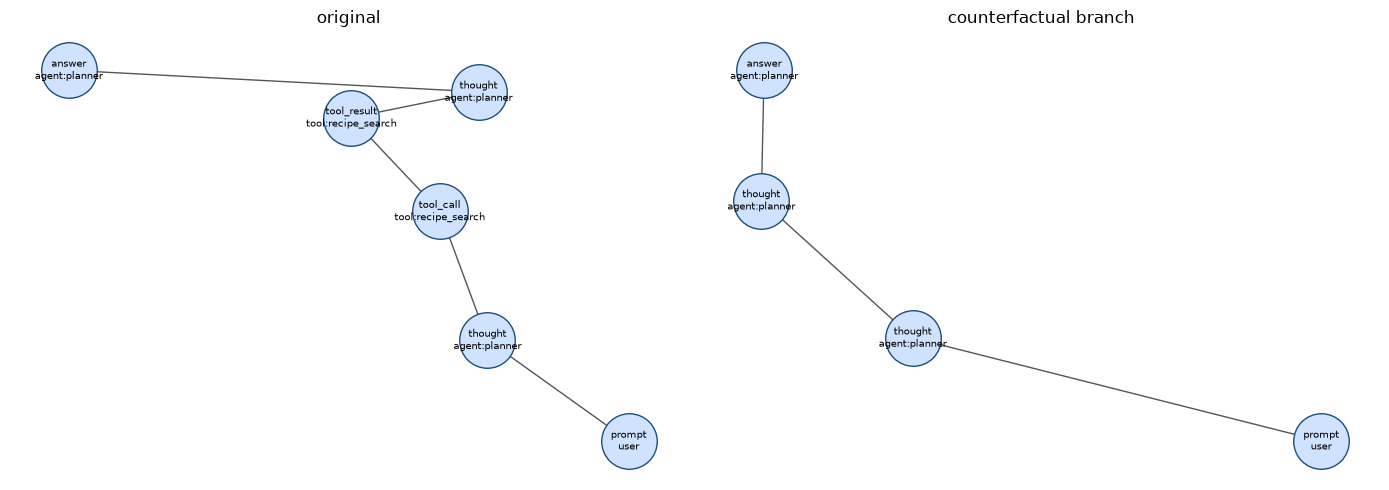

In [17]:
# Render the original DAG and the branched DAG side-by-side.
import matplotlib.pyplot as plt
import networkx as nx

def to_nx(ch: Chronicle) -> nx.DiGraph:
    g = nx.DiGraph()
    for evt in ch:
        g.add_node(evt.id[:6], label=f'{evt.kind}\n{evt.actor}')
        for p in evt.parents:
            g.add_edge(p[:6], evt.id[:6])
    return g

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ch, title in zip(axes, [c, branch], ['original', 'counterfactual branch']):
    g = to_nx(ch)
    try:
        pos = nx.nx_agraph.graphviz_layout(g, prog='dot')
    except Exception:
        pos = nx.spring_layout(g, seed=42)
    nx.draw_networkx_nodes(g, pos, ax=ax, node_size=1600, node_color='#cfe2ff', edgecolors='#1f4e79')
    nx.draw_networkx_edges(g, pos, ax=ax, arrowsize=15, edge_color='#555')
    labels = {n: g.nodes[n]['label'] for n in g.nodes}
    nx.draw_networkx_labels(g, pos, labels=labels, ax=ax, font_size=7)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


### Check 7 — JSONL round-trip

In [18]:
import tempfile, os
with tempfile.NamedTemporaryFile(suffix='.jsonl', delete=False) as f:
    path = f.name
c.dump(path)
loaded = Chronicle.load(path)
assert loaded.root() == c.root(), 'roundtripped Chronicle must have the same root'
ok, bad = loaded.verify()
assert ok, bad
os.unlink(path)
print(f'PASS — JSONL round-trip preserves the Merkle root: {c.root()}')


PASS — JSONL round-trip preserves the Merkle root: 4c3a83306ce1525e990d22188ccd24ee


## §10 Build the wheel

Now that all checks pass on the in-tree source, we write `pyproject.toml` and a minimal `README.md`, invoke `python -m build --wheel`, and confirm the artifact lands in `dist/`.


In [19]:
_SRC = r'''[build-system]
requires = ["hatchling"]
build-backend = "hatchling.build"

[project]
name = "chronicle"
version = "0.1.0"
description = "Merkle-DAG agent traceability with causal, integrity, and semantic views."
readme = "README.md"
requires-python = ">=3.10"
license = { text = "MIT" }
authors = [{ name = "Sanjay Babu" }]
dependencies = [
    "numpy>=1.24",
]

[project.optional-dependencies]
st = ["sentence-transformers>=2.2"]

[tool.hatch.build.targets.wheel]
packages = ["src/chronicle"]
'''
from pathlib import Path
_p = Path('pyproject.toml'); _p.parent.mkdir(parents=True, exist_ok=True)
_p.write_text(_SRC, encoding='utf-8')
print(f'wrote {_p} ({len(_SRC)} bytes)')


wrote pyproject.toml (494 bytes)


In [20]:
_SRC = r'''# chronicle

Merkle-DAG agent traceability. Built from `notebook/chronicle.ipynb`.

```python
import chronicle
c = chronicle.demo()
print("root:", c.root())
print("verify:", c.verify())
for evt, score in c.search("vegan recipe"):
    print(f"{score:+.3f}  {evt.kind:<12} {evt.actor}")
```

See the notebook for the design and the headline properties:
deterministic cross-run identity, tamper detection, causal `why()`,
semantic search, and counterfactual branching.
'''
from pathlib import Path
_p = Path('README.md'); _p.parent.mkdir(parents=True, exist_ok=True)
_p.write_text(_SRC, encoding='utf-8')
print(f'wrote {_p} ({len(_SRC)} bytes)')


wrote README.md (466 bytes)


In [21]:
import subprocess, sys
# Use the *current* interpreter so the wheel is built in the active venv.
r = subprocess.run(
    [sys.executable, '-m', 'build', '--wheel', '--no-isolation'],
    capture_output=True, text=True
)
print(r.stdout[-2000:])
if r.returncode != 0:
    print('STDERR:', r.stderr[-2000:])
    raise SystemExit(r.returncode)

from pathlib import Path
wheels = sorted(Path('dist').glob('chronicle-*.whl'))
assert wheels, 'no wheel was produced'
WHEEL = wheels[-1]
print('built:', WHEEL)


Successfully built chronicle-0.1.0-py3-none-any.whl

built: dist/chronicle-0.1.0-py3-none-any.whl


## §11 Install the wheel and import it

We install the just-built wheel into the active Python and reload `chronicle` from site-packages (rather than the src tree we've been using all along). If `demo()` runs and `verify()` passes, the wheel is sound.


In [22]:
import subprocess, sys, importlib
r = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--force-reinstall', '--no-deps', '--quiet', str(WHEEL)],
    capture_output=True, text=True,
)
print(r.stdout, r.stderr)
assert r.returncode == 0

# Drop the src/ shim from sys.path so we import the *installed* package.
sys.path = [p for p in sys.path if 'src' not in p.split('/')[-2:]]
for mod in list(sys.modules):
    if mod == 'chronicle' or mod.startswith('chronicle.'):
        del sys.modules[mod]
import chronicle
print('imported chronicle', chronicle.__version__, 'from', chronicle.__file__)

c = chronicle.demo()
ok, bad = c.verify()
assert ok, bad
print(f'demo Chronicle: {len(c)} events, root={c.root()}, verify=OK')
for evt, score in c.search('vegan recipe ingredients'):
    print(f'  {score:+.3f}  {evt.kind:<12} {evt.actor:<18} {str(evt.payload)[:60]}')


 
imported chronicle 0.1.0 from /Users/sanjaybabu/Documents/LLM/.venv/lib/python3.12/site-packages/chronicle/__init__.py
demo Chronicle: 6 events, root=4309fb0d6d1981f6c6657e14dbe13a76, verify=OK
  +0.272  thought      agent:planner      {'text': 'found 4 ingredients; assembling the answer'}
  +0.168  prompt       user               {'text': 'find me a vegan lasagna recipe'}
  +0.156  tool_call    tool:recipe_search {'name': 'recipe_search', 'args': ['vegan lasagna'], 'kwargs
  +0.151  thought      agent:planner      {'text': "the user wants a vegan lasagna recipe; I'll search
  +0.112  answer       agent:planner      {'text': "Here's a vegan lasagna using: tofu ricotta, cashew


## §12 Research notes & next steps

**The contribution.** Treating an agent trace as a content-addressed causal DAG with a semantic overlay collapses *causality, integrity, cross-run comparison, search, and counterfactual replay* into a single substrate, rather than requiring orthogonal subsystems for each. The headline property is **deterministic cross-run identity** — identical reasoning produces identical ids, making A/B comparison of agent variants exact.

**Limitations of this prototype.**
- Only the hashing-trick embedder is exercised in the smoke test; the   `SentenceTransformerEmbedder` adapter is included but optional.
- In-memory only. Persistence is JSONL — fine for research scale, not for   long-running production agents.
- No cryptographic signatures yet. Tamper detection is integrity-only;   add signed Merkle roots (Ed25519) for adversarial-robustness work.
- No OpenTelemetry bridge. Adding an exporter would let traces flow into   Jaeger / Tempo / Langfuse for cross-comparison with span-tree tools.

**Citing this design.** If you publish, the framing to lean on is: "agent traces as Merkle DAGs with semantic overlay — a unified substrate for causality, integrity, and counterfactual analysis". As far as I can find, this combined framing is not present in the existing agent-observability literature.
